**BELOW WE INSTALL NECESSARY PACKAGES**

In [ ]:
!pip install "gymnasium[atari, accept-rom-license]"

In [ ]:
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

Import necessary packages

In [ ]:
import gymnasium
import ale_py

**BELOW WE DEFINE ALL THE CLASSES TO TRAIN THE MODELS**

In [ ]:
import cv2
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import random

# Preprocess a single frame (resize to 84x84, grayscale, normalize)
def preprocess_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
    normalized = resized.astype(np.float32) / 255.0
    return normalized

# Stack 4 frames to give the agent temporal information
class FrameStack:
    def __init__(self, k):
        self.k = k
        self.frames = deque([], maxlen=k)

    def reset(self, obs):
        frame = preprocess_frame(obs)
        for _ in range(self.k):
            self.frames.append(frame)
        return np.stack(self.frames, axis=0)

    def step(self, obs):
        frame = preprocess_frame(obs)
        self.frames.append(frame)
        return np.stack(self.frames, axis=0)


In [ ]:
# Define the actual model network
class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
# Replay memory class
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.uint8)
        )

    def __len__(self):
        return len(self.buffer)

In [ ]:
# Class to evaluate the models
def evaluate_policy_epsilon_greedy(env, model, stacker, device='cpu', episodes=10, epsilon=0.05, render=False):
    model.eval()
    total_rewards = []

    for ep in range(episodes):
        obs, _ = env.reset()
        state = stacker.reset(obs)
        episode_reward = 0
        done = False

        while not done:
            if render:
                env.render()

            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                    q_values = model(state_tensor)
                    action = q_values.argmax().item()

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = stacker.step(next_obs)
            episode_reward += reward

        total_rewards.append(episode_reward)
        print(f"Eval Episode {ep+1}: Reward = {episode_reward:.2f}")

    avg_reward = np.mean(total_rewards)
    print(f"\nAverage Evaluation Reward over {episodes} episodes: {avg_reward:.2f}")
    return avg_reward


In [ ]:
# Define the Frame Skipper class
import numpy as np
import gymnasium

class MaxAndSkipEnv(gymnasium.Wrapper):
    def __init__(self, env, skip=4):
        super().__init__(env)
        self._obs_buffer = np.zeros((2,) + env.observation_space.shape, dtype=np.uint8)
        self._skip = skip

    def step(self, action):
        total_reward = 0.0
        done = False
        for i in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            if i == self._skip - 2: self._obs_buffer[0] = obs
            if i == self._skip - 1: self._obs_buffer[1] = obs
            total_reward += reward
            done = terminated or truncated
            if done:
                break
        max_frame = np.maximum(self._obs_buffer[0], self._obs_buffer[1])
        return max_frame, total_reward, terminated, truncated, info

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)


**BELOW WE DEFINE AND TRAIN THE MODEL**

In [ ]:
# Train with the Frame Skipping technique the paper uses
import time
from datetime import timedelta

env = gymnasium.make("ALE/Pong-v5", render_mode=None)
env = MaxAndSkipEnv(env, skip=4)
stacker = FrameStack(4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model2 = DQN((4, 84, 84), env.action_space.n).to(device)
target_model = DQN((4, 84, 84), env.action_space.n).to(device)
target_model.load_state_dict(model2.state_dict())

optimizer = optim.Adam(model2.parameters(), lr=1e-4)
buffer = ReplayBuffer(100000) # Increase replay buffer from 10,000 to 100,000

# Epsilon setup (linear decay)
epsilon = 1.0
epsilon_final = 0.1
epsilon_decay_episodes = 1500
epsilon_decay = (epsilon - epsilon_final) / epsilon_decay_episodes

gamma = 0.99
batch_size = 32
sync_target_steps = 1000
total_steps = 0

# Collect fixed evaluation states using a random policy before training
fixed_eval_states = []

obs, _ = env.reset()
state = stacker.reset(obs)

while len(fixed_eval_states) < 100:  # use 100 fixed states as in the paper
    action = env.action_space.sample()
    next_obs, _, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state = stacker.step(next_obs)
    fixed_eval_states.append(state.copy())
    if done:
        obs, _ = env.reset()
        state = stacker.reset(obs)

# Convert fixed states to tensor
fixed_eval_tensor = torch.tensor(np.array(fixed_eval_states), dtype=torch.float32, device=device)

env_eval = gymnasium.make("ALE/Pong-v5", render_mode="rgb_array")
env_eval = MaxAndSkipEnv(env_eval, skip=4)

episode_rewards = []
average_q_values = []

start_time = time.time()

for episode in range(2000):
    obs, _ = env.reset()
    state = stacker.reset(obs)
    episode_reward = 0
    done = False
    q_values_this_episode = []

    while not done:
        total_steps += 1

        # Epsilon-greedy action
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                q_values = model2(state_tensor)
                action = q_values.argmax().item()
                q_values_this_episode.append(q_values.max().item())

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = stacker.step(next_obs)
        buffer.push(state, action, reward, next_state, done)
        state = next_state
        episode_reward += reward

        # Learn
        if len(buffer) > 2000: # increase number of transitions to train on
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)

            states_tensor = torch.tensor(states, dtype=torch.float32, device=device)
            actions_tensor = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
            rewards_tensor = torch.tensor(rewards, device=device)
            next_states_tensor = torch.tensor(next_states, dtype=torch.float32, device=device)
            dones_tensor = torch.tensor(dones, dtype=torch.bool, device=device)

            q_values = model2(states_tensor).gather(1, actions_tensor).squeeze()
            with torch.no_grad():
                next_q = target_model(next_states_tensor).max(1)[0]
                target_q = rewards_tensor + gamma * next_q * (~dones_tensor)

            loss = nn.MSELoss()(q_values, target_q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if total_steps % sync_target_steps == 0:
                target_model.load_state_dict(model2.state_dict())

    # Linearly decay epsilon
    if epsilon > epsilon_final:
        epsilon -= epsilon_decay
        epsilon = max(epsilon, epsilon_final)

    # Record stats
    episode_rewards.append(episode_reward)
    # Compute average max Q over fixed evaluation states
    with torch.no_grad():
        q_eval = model2(fixed_eval_tensor)
        avg_q = q_eval.max(1)[0].mean().item()
    average_q_values.append(avg_q)

    # Print episode summary

    print(f"Episode {episode}, Reward: {episode_reward:.2f}, Epsilon: {epsilon:.3f}, Avg Max Q: {avg_q:.2f}")

    if (episode + 1) % 200 == 0:
        print(f"\n📊 Evaluating model at episode {episode+1}...")
        evaluate_policy_epsilon_greedy(env_eval, model2, stacker, device=device, episodes=10, epsilon=0.05, render=False)

end_time = time.time()
elapsed_time = int(end_time - start_time)
formatted_time = str(timedelta(seconds=elapsed_time))
print(f"\nTraining completed in {formatted_time}.")

Episode 0, Reward: -21.00, Epsilon: 0.999, Avg Max Q: 0.04
Episode 1, Reward: -20.00, Epsilon: 0.999, Avg Max Q: 0.04
Episode 2, Reward: -19.00, Epsilon: 0.998, Avg Max Q: 0.04
Episode 3, Reward: -21.00, Epsilon: 0.998, Avg Max Q: 0.04
Episode 4, Reward: -21.00, Epsilon: 0.997, Avg Max Q: 0.04
Episode 5, Reward: -20.00, Epsilon: 0.996, Avg Max Q: 0.04
Episode 6, Reward: -19.00, Epsilon: 0.996, Avg Max Q: 0.04
Episode 7, Reward: -21.00, Epsilon: 0.995, Avg Max Q: 0.04
Episode 8, Reward: -21.00, Epsilon: 0.995, Avg Max Q: -0.01
Episode 9, Reward: -20.00, Epsilon: 0.994, Avg Max Q: -0.04
Episode 10, Reward: -21.00, Epsilon: 0.993, Avg Max Q: -0.03
Episode 11, Reward: -21.00, Epsilon: 0.993, Avg Max Q: -0.04
Episode 12, Reward: -20.00, Epsilon: 0.992, Avg Max Q: 0.01
Episode 13, Reward: -21.00, Epsilon: 0.992, Avg Max Q: -0.09
Episode 14, Reward: -21.00, Epsilon: 0.991, Avg Max Q: -0.07
Episode 15, Reward: -21.00, Epsilon: 0.990, Avg Max Q: -0.04
Episode 16, Reward: -20.00, Epsilon: 0.990,

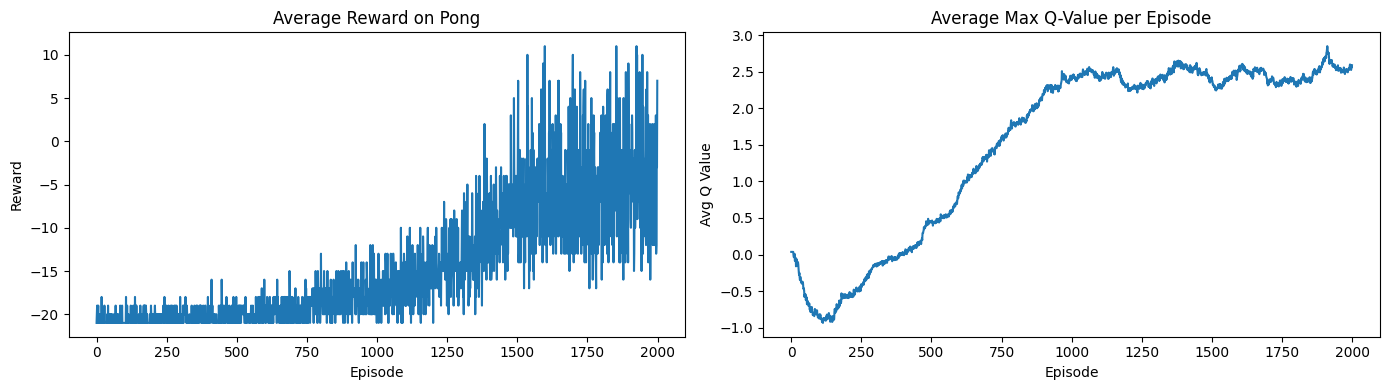

In [ ]:
# Plot Training curves
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Average Reward per Episode
axs[0].plot(episode_rewards)
axs[0].set_title('Average Reward on Pong')
axs[0].set_xlabel('Episode')
axs[0].set_ylabel('Reward')

# Average Max Q Value per Episode
axs[1].plot(average_q_values)
axs[1].set_title('Average Max Q-Value per Episode')
axs[1].set_xlabel('Episode')
axs[1].set_ylabel('Avg Q Value')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate Final Model
evaluate_policy_epsilon_greedy(env_eval, model2, stacker, device=device, episodes=10, epsilon=0.05, render=True)
evaluate_policy_epsilon_greedy(env_eval, model2, stacker, device=device, episodes=10, epsilon=0, render=True)

Eval Episode 1: Reward = 1.00
Eval Episode 2: Reward = 10.00
Eval Episode 3: Reward = 9.00
Eval Episode 4: Reward = 5.00
Eval Episode 5: Reward = 2.00
Eval Episode 6: Reward = -11.00
Eval Episode 7: Reward = 3.00
Eval Episode 8: Reward = 13.00
Eval Episode 9: Reward = 9.00
Eval Episode 10: Reward = -10.00

Average Evaluation Reward over 10 episodes: 3.10
Eval Episode 1: Reward = 2.00
Eval Episode 2: Reward = 1.00
Eval Episode 3: Reward = 6.00
Eval Episode 4: Reward = 2.00
Eval Episode 5: Reward = 11.00
Eval Episode 6: Reward = 5.00
Eval Episode 7: Reward = 6.00
Eval Episode 8: Reward = 5.00
Eval Episode 9: Reward = 8.00
Eval Episode 10: Reward = 14.00

Average Evaluation Reward over 10 episodes: 6.00


np.float64(6.0)

Text(0, 0.5, 'Average Reward')

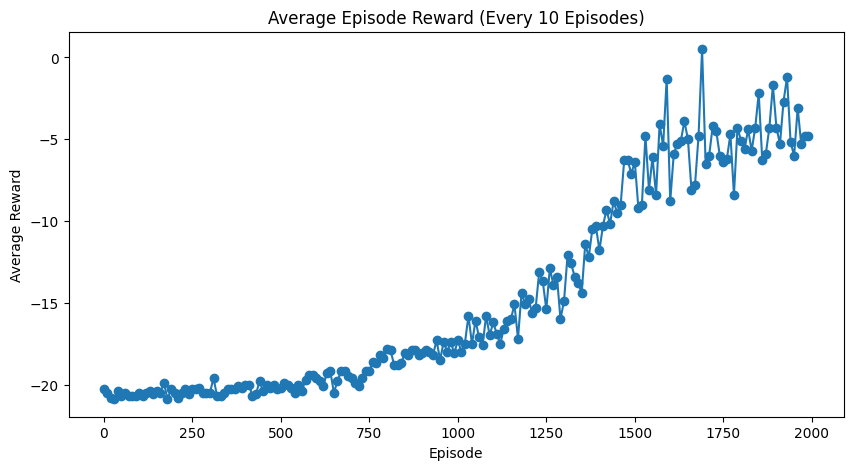

In [ ]:
# Plot episode rewards, averaging over every 10 episodes
smoothed_rewards = []
window=10
for i in range(0, len(episode_rewards), window):
    chunk = episode_rewards[i:i+window]
    avg = np.mean(chunk)
    smoothed_rewards.append(avg)

x = np.arange(len(smoothed_rewards)) * window  # episode indices

plt.figure(figsize=(10, 5))
plt.plot(x, smoothed_rewards, marker='o')
plt.title(f'Average Episode Reward (Every {window} Episodes)')
plt.xlabel('Episode')
plt.ylabel('Average Reward')